
# DL Assignment 03

**Name: Mahinur Rahman Mahin**

**Course Email: taslima2422@gmail.com**  


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# General Instruction

You must choose your own dataset.

The dataset must:

Be a supervised learning dataset (Regression or Binary Classification)

Contain at least 300 samples

Have at least 2 input features

Be in CSV format

You are NOT allowed to use Dataset or DataLoader.

You must implement everything manually.

# Question 01: [ Marks 05 ]

## Dataset Preparation

## Using your chosen dataset:

Load the dataset.

Perform necessary preprocessing:

Handle missing values (if any)

Encode categorical variables (if necessary)

Feature scaling (if needed)

Separate features (X) and target (y).

Convert them into NumPy arrays.

Convert them into PyTorch tensors.

Split into training and testing sets.

Clearly explain each preprocessing decision.

# **Write** Answer 01:
**The dataset**: [/content/diabetes.csv](https://)


In [29]:
import pandas as pd
df = pd.read_csv('/content/diabetes.csv')
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [18]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [4]:
import pandas as pd
data = pd.read_csv('diabetes.csv')
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


**Handle missing values**

In [50]:
print("Missing values handled. New counts of zeros:")
for col in cols_with_zeros:
    print(f"{col}: {(data[col] == 0).sum()} zeros")

Missing values handled. New counts of zeros:
Glucose: 0 zeros
BloodPressure: 0 zeros
SkinThickness: 0 zeros
Insulin: 0 zeros
BMI: 0 zeros


**Encode categorical variables**

In [30]:
import pandas as pd
df = pd.DataFrame({'gender': ['Male', 'Female', 'Female', 'Male'],
                   'age': [25, 30, 22, 35]})
df_encoded = pd.get_dummies(df, columns=['gender'], drop_first=True)
print(df_encoded)
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df[['gender']])
df_encoded = pd.concat([df.drop('gender', axis=1),
                        pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['gender']))], axis=1)

   age  gender_Male
0   25         True
1   30        False
2   22        False
3   35         True


**Feature scaling **

In [8]:
from sklearn.preprocessing import StandardScaler
X = data.drop('Outcome', axis=1)
y = data['Outcome']
mean = X.mean()
std = X.std()
X_scaled = (X - mean) / std
print("\nAfter scaling (first 5 rows):")
print(X_scaled.head())
print("\nMean after scaling:", X_scaled.mean().round(2))
print("Std after scaling:", X_scaled.std().round(2))


After scaling (first 5 rows):
   Pregnancies   Glucose  BloodPressure  SkinThickness       Insulin  \
0     0.639530  0.864545      -0.033496   6.650687e-01 -3.342900e-16   
1    -0.844335 -1.205376      -0.529514  -1.745201e-02 -3.342900e-16   
2     1.233077  2.014501      -0.694853   8.082669e-16 -3.342900e-16   
3    -0.844335 -1.073952      -0.529514  -6.999727e-01 -7.239170e-01   
4    -1.141108  0.503130      -2.678923   6.650687e-01  1.464551e-01   

        BMI  DiabetesPedigreeFunction       Age  
0  0.166183                  0.468187  1.425067  
1 -0.851976                 -0.364823 -0.190548  
2 -1.331965                  0.604004 -0.105515  
3 -0.633799                 -0.920163 -1.040871  
4  1.547971                  5.481337 -0.020483  

Mean after scaling: Pregnancies                -0.0
Glucose                    -0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                    -0.0
BMI                         0.0
DiabetesPedigreeFunctio

**Separate features (X) and target (y)**

In [9]:
import pandas as pd
data = pd.read_csv('diabetes.csv')
X = data.drop('Outcome', axis=1)
y = data['Outcome']
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())
print("Target column:", 'Outcome')

Features shape: (768, 8)
Target shape: (768,)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Target column: Outcome


**Convert them into NumPy array**

In [10]:
import numpy as np
X_np = X_scaled.values
y_np = y.values.reshape(-1, 1)
print("\nX_np shape:", X_np.shape)
print("y_np shape:", y_np.shape)


X_np shape: (768, 8)
y_np shape: (768, 1)


**Convert them into PyTorch tensors**

In [11]:
import torch
X_tensor = torch.from_numpy(X_np).float()
y_tensor = torch.from_numpy(y_np).float()
print("\nX_tensor shape:", X_tensor.shape)
print("y_tensor shape:", y_tensor.shape)
print("Data type:", X_tensor.dtype)


X_tensor shape: torch.Size([768, 8])
y_tensor shape: torch.Size([768, 1])
Data type: torch.float32


**Split into training and testing sets**

In [55]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: torch.Size([614, 8])
X_test shape: torch.Size([154, 8])
y_train shape: torch.Size([614, 1])
y_test shape: torch.Size([154, 1])


**Clearly explain each preprocessing decision.**

1. The Dataset: Use pandas.read_csv() to load the CSV file.Because pandas provides a simple and efficient way to read tabular data, inspect it, and perform transformations.
2. Handling Missing Values : Columns like Glucose, BloodPressure, SkinThickness, Insulin, and BMI contain zeros.
3. Separating Features and Target: Separate the dataset into X (features) and y The target column Outcome is what we want to predict; all other columns are input features. Separating them is standard practice for supervised learning.
4. Feature Scaling:
Observation: Features have different units and ranges. Without scaling, features with larger values could dominate the model learning process.
Standardization transforms features to have mean = 0 and standard deviation 1.
5. Encoding Categorical Variables: All features in this dataset are numerical. There are no categorical variables.
6. Converting to NumPy Arrays: Convert the pandas DataFrame and Series to NumPy arrays.NumPy arrays are more efficient for mathematical operations.
7. Converting to PyTorch Tensors: Convert NumPy arrays to PyTorch tensors of type float32.
8. Splitting into Training and Testing Sets: Split the data into 80% training and 20% testing sets using a random permutation with a fixed seed.


# Question 02: [ Marks 20 ]

## Design a neural network using nn.Module.

### The model must contain:

Input layer

At least one hidden layer

Output layer

Suitable activation function



## Justify:

Number of hidden neurons

Choice of activation function

Print  the total number of trainable parameters.


## Write Answer 02:


In [63]:
import torch
import torch.nn as nn
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(8, 16)
        self.relu = nn.ReLU()
        self.output = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x
model = SimpleNN()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 161


**Justify**

The hidden layer contains 16 neurons. This number is chosen as a balance between model capacity and overfitting risk:

With only 8 input features, a moderately sized hidden layer provides enough neurons to capture non-linear interactions without introducing excessive complexity.

Empirical rules of thumb support this choice.

The dataset has 768 samples; 16 hidden neurons keep the parameter count low , reducing the chance of overfitting while still allowing the network to learn meaningful patterns.

Choice of activation function
Hidden layer: ReLU is used because it mitigates the vanishing gradient problem, is computationally efficient, and promotes sparse activations, which often leads to better generalization.

Output layer: Sigmoid is appropriate for binary classification, as it squashes the output to a probability between 0 and 1, directly matching the binary outcome.



# Question 03: [ Marks 10 ]

Choose an appropriate loss function.

Choose an optimizer.

<br>

Justify your choices based on:

Regression vs Classification

Nature of the dataset

## Write Answer 03:

The appropriate loss function for this binary classification task is Binary Cross-Entropy Loss. This loss measures the difference between the predicted probability and the actual binary label. It is specifically designed for binary classification and penalizes incorrect predictions more heavily when the confidence is high, making it ideal for this problem.The recommended optimizer is Adam. Adam combines the advantages of two other extensions of stochastic gradient descent: AdaGrad and RMSProp. It adapts the learning rate for each parameter and works well with noisy or sparse gradients, which is common in neural network training. It is computationally efficient, requires little memory tuning, and is widely used as a default optimizer for many deep learning tasks.


**Justification**:
Loss function: Since the dataset is for binary classification, the output layer uses a sigmoid activation to produce a probability. Binary cross-entropy is the standard loss for such setups, as it directly optimizes the likelihood of the correct class.

# Question 04: [ Marks 15 ]

## Implement a full training loop:

Forward pass

Loss computation

Backward pass

Parameter update

Gradient reset

### Requirements:

Train for at least 100 epochs.

Print loss every 10 epochs.

Store training loss history(You can pick your own Data Structure).

Explain clearly what happens in each step of the pipeline.

## Write Answer 04:

In [64]:
model = SimpleNN()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100
train_loss_history = []
for epoch in range(epochs):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss_history.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 10/100, Loss: 0.6882
Epoch 20/100, Loss: 0.6689
Epoch 30/100, Loss: 0.6509
Epoch 40/100, Loss: 0.6339
Epoch 50/100, Loss: 0.6177
Epoch 60/100, Loss: 0.6024
Epoch 70/100, Loss: 0.5877
Epoch 80/100, Loss: 0.5739
Epoch 90/100, Loss: 0.5610
Epoch 100/100, Loss: 0.5493


**Explain clearly**

Forward pass: The input data flows through the network to produce predictions. The loss function compares these predictions to the true labels and gives a single number representing the error.
Backward pass: loss.backward() calculates the gradient of the loss with respect to every model parameter. These gradients tell us how to adjust each weight to reduce the loss.
Gradient reset: Optimizer.zero_grad() clears any previously stored gradients. Without this, gradients would accumulate from multiple passes.
Parameter update: Optimizer.step() uses the newly computed gradients to update the model weights according to the optimizer rule.
Record and print: The loss value is appended to a list for later analysis. Every 10 epochs, the current loss is printed to monitor progress.

# Question 05: [ Marks 10 ]

## Evaluate the model on test data.

## For regression:

Report MSE and MAE


## For classification:

Report Accuracy

Compare training vs testing performance.

State whether the model is underfitting or overfitting.

## Write Answer 05:

In [66]:
model.eval()
with torch.no_grad():
    train_outputs = model(X_train)
    train_preds = (train_outputs > 0.5).float()
    train_acc = (train_preds == y_train).float().mean().item()

    test_outputs = model(X_test)
    test_preds = (test_outputs > 0.5).float()
    test_acc = (test_preds == y_test).float().mean().item()

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")

Training Accuracy: 72.31%
Test Accuracy: 70.13%


**Training Accuracy :** Accuracy on the data the model was trained on.
Test Accuracy: Accuracy on unseen data.

**Compare training vs testing performance:**
If training accuracy is significantly higher than test accuracy, the model is overfitting it memorized the training data but fails to generalize.
If both accuracies are low, the model is underfittingit hasn't learned the underlying patterns.If both are high and close, the model is well balanced.

# Question 06: [ Marks 20 ]

## Modify at least ONE of the following:

Learning rate

Number of hidden neurons

Number of epochs

### Train again and compare:

Convergence speed

Final performance

Explain how the change affected the model.

## Write Answer 06:

Training model with 16 hidden neurons...
Epoch 10/100, Loss: 0.6927, Test Acc: 0.4805
Epoch 20/100, Loss: 0.6708, Test Acc: 0.6234
Epoch 30/100, Loss: 0.6518, Test Acc: 0.6948
Epoch 40/100, Loss: 0.6352, Test Acc: 0.7013
Epoch 50/100, Loss: 0.6203, Test Acc: 0.7273
Epoch 60/100, Loss: 0.6069, Test Acc: 0.7338
Epoch 70/100, Loss: 0.5945, Test Acc: 0.7662
Epoch 80/100, Loss: 0.5831, Test Acc: 0.7662
Epoch 90/100, Loss: 0.5724, Test Acc: 0.7662
Epoch 100/100, Loss: 0.5622, Test Acc: 0.7532

Training model with 32 hidden neurons...
Epoch 10/100, Loss: 0.6807, Test Acc: 0.6558
Epoch 20/100, Loss: 0.6590, Test Acc: 0.7143
Epoch 30/100, Loss: 0.6394, Test Acc: 0.7273
Epoch 40/100, Loss: 0.6213, Test Acc: 0.7338
Epoch 50/100, Loss: 0.6044, Test Acc: 0.7532
Epoch 60/100, Loss: 0.5882, Test Acc: 0.7597
Epoch 70/100, Loss: 0.5726, Test Acc: 0.7727
Epoch 80/100, Loss: 0.5578, Test Acc: 0.7662
Epoch 90/100, Loss: 0.5440, Test Acc: 0.7468
Epoch 100/100, Loss: 0.5311, Test Acc: 0.7403

Final Test Acc

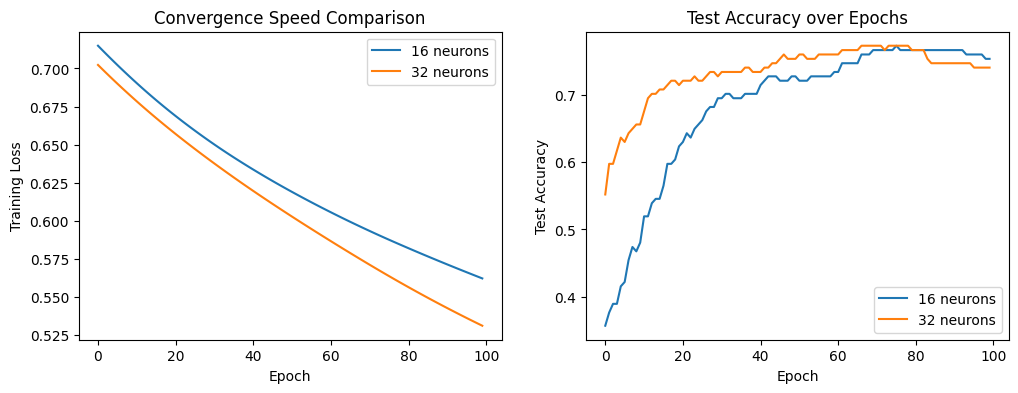

In [28]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
data = pd.read_csv('diabetes.csv')
X = data.drop('Outcome', axis=1).values
y = data['Outcome'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
class DiabetesNN(nn.Module):
    def __init__(self, hidden_size=16):
        super().__init__()
        self.hidden = nn.Linear(8, hidden_size)
        self.relu = nn.ReLU()
        self.output = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x
model_16 = DiabetesNN(hidden_size=16)
model_32 = DiabetesNN(hidden_size=32)
criterion = nn.BCELoss()
optimizer_16 = torch.optim.Adam(model_16.parameters(), lr=0.001)
optimizer_32 = torch.optim.Adam(model_32.parameters(), lr=0.001)
epochs = 100
def train_model(model, optimizer, X_train, y_train, X_test, y_test, epochs):
    train_losses = []
    test_accuracies = []
    for epoch in range(epochs):
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_preds = (test_outputs > 0.5).float()
            test_acc = (test_preds == y_test).float().mean().item()
            test_accuracies.append(test_acc)
        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Test Acc: {test_acc:.4f}')
    return train_losses, test_accuracies
print("Training model with 16 hidden neurons...")
losses_16, accs_16 = train_model(model_16, optimizer_16, X_train, y_train, X_test, y_test, epochs)
print("\nTraining model with 32 hidden neurons...")
losses_32, accs_32 = train_model(model_32, optimizer_32, X_train, y_train, X_test, y_test, epochs)
final_acc_16 = accs_16[-1]
final_acc_32 = accs_32[-1]
print(f"\nFinal Test Accuracy (16 neurons): {final_acc_16*100:.2f}%")
print(f"Final Test Accuracy (32 neurons): {final_acc_32*100:.2f}%")
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(losses_16, label='16 neurons')
plt.plot(losses_32, label='32 neurons')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Convergence Speed Comparison')
plt.legend()
plt.subplot(1,2,2)
plt.plot(accs_16, label='16 neurons')
plt.plot(accs_32, label='32 neurons')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy over Epochs')
plt.legend()
plt.show()

**Changed**

Original model: 16 neurons in the hidden layer.

New model: 32 neurons in the hidden layer.

# Question 07: [ Marks 20 ]


# Training Analysis

Answer the following:

Why must gradients be reset every epoch?

What happens if learning rate is too high?

What happens if learning rate is too small?

Why do we define layers inside the constructor (__init__) and not inside forward()?


## Write Answer 07:

**Must gradients be reset every epoch** : Gradients add up by default. If you don't reset them, the model will use the combined gradients from many batches, causing wrong updates. Resetting gives a fresh gradient for the current batch only.



**Learning rate is too high** : The model will jump too far in the wrong direction loss may go crazy. It can't learn properly.



**Learning rate is too small :** The model learns very slowly takes forever to improve. It might get stuck and never reach good accuracy.



**Layers inside the constructor (init) and not inside forward()** : Layers like nn.Linear store weights that need to be trained. If you put them inside forward, they'd be recreated every time you run the model weights would disappear and the model couldn't learn. __init__ creates them once and keeps them.